# 15m Rolling Johansen OOS Backtest

이 노트북은 앞서 만든 **1m_backtest와 동일한 구조**로 15분봉 후보 바스켓을 검증합니다.

`Johansen_test_15m`의 최종 선별 결과에서 다음 두 바스켓을 사용합니다.

1. BTC-ADA-DOT-TRX
2. BTC-LINK-SOL-TRX

백테스트 구조:
- 원본 1분봉 데이터를 15분봉으로 리샘플링
- 90일 Train → 7일 Test → 7일씩 이동
- 각 Train window에서 Johansen trace test와 cointegrating vector를 다시 추정
- Test에서 rank < 1이면 해당 7일은 거래하지 않음
- z-score는 trailing 14일 정보만 사용
- 진입: |z| ≥ 2.0
- 청산: 평균 근처 복귀 (`long: z ≥ -0.5`, `short: z ≤ 0.5`)
- 각 OOS window 종료 시 강제청산
- 기본 수수료 5bps + 슬리피지 0/5/10bps
- 실제 PnL용 weight는 gross exposure 합이 1이 되도록 정규화

15분봉 screening에서 사용된 Johansen 차수:
- BTC-ADA-DOT-TRX: `k_ar_diff = 8`
- BTC-LINK-SOL-TRX: `k_ar_diff = 9`

> 주의: 후보 바스켓 자체가 2025년 전체 데이터를 이용해 먼저 선별된 것이므로,
> 이 백테스트는 **고정 후보의 rolling OOS 안정성/수익성 검증**입니다.
> 후보 선택까지 완전히 OOS로 만들려면 각 Train window 안에서 후보 탐색부터 다시 해야 합니다.

In [1]:
!pip install -q statsmodels pyarrow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.vector_ar.vecm import coint_johansen
from google.colab import drive

drive.mount('/content/drive')

PATH = "/content/drive/MyDrive/코인데이터/ALL_1m.parquet"

# 1분봉 원본
df_1m = pd.read_parquet(PATH).sort_index()
df_1m = df_1m.loc["2025-01-01":"2025-12-31"]

# 15분봉: 각 15분 구간의 마지막 가격
df = df_1m.resample("15min").last()

print("1m shape :", df_1m.shape)
print("15m shape:", df.shape)
print("period   :", df.index.min(), "~", df.index.max())
print("columns  :", df.columns.tolist())

Mounted at /content/drive
1m shape : (525600, 10)
15m shape: (35040, 10)
period   : 2025-01-01 00:00:00+00:00 ~ 2025-12-31 23:45:00+00:00
columns  : ['KRW-ADA', 'KRW-AVAX', 'KRW-BTC', 'KRW-DOGE', 'KRW-DOT', 'KRW-ETH', 'KRW-LINK', 'KRW-SOL', 'KRW-TRX', 'KRW-XRP']


In [3]:
# Johansen_test_15m에서 최종 선별된 2개 후보

BASKETS = [
    ["KRW-BTC", "KRW-ADA", "KRW-DOT", "KRW-TRX"],
    ["KRW-BTC", "KRW-LINK", "KRW-SOL", "KRW-TRX"],
]

K_AR_DIFF_BY_BASKET = {
    "KRW-BTC|KRW-ADA|KRW-DOT|KRW-TRX": 8,
    "KRW-BTC|KRW-LINK|KRW-SOL|KRW-TRX": 9,
}

BAR_MINUTES = 15
BARS_PER_HOUR = 60 // BAR_MINUTES
BARS_PER_DAY = 24 * BARS_PER_HOUR

TRAIN_DAYS = 90
TEST_DAYS = 7
STEP_DAYS = 7
ZSCORE_DAYS = 14

ENTRY_Z = 2.0
EXIT_Z = 0.5

DET_ORDER = 0
ALPHA_TRACE = 0.05

BASE_TC_BPS = 5.0
SLIPPAGE_CASES = [0.0, 5.0, 10.0]

# time-based rolling에서 최소 관측치
# 14일 window를 쓰되 최소 7일 데이터가 쌓인 이후 z-score 허용
MIN_Z_OBS = 7 * BARS_PER_DAY

# Train 90일 중 최소 60일 이상의 유효 15분봉이 있어야 실행
MIN_TRAIN_OBS = 60 * BARS_PER_DAY

print("BARS_PER_DAY :", BARS_PER_DAY)
print("MIN_Z_OBS    :", MIN_Z_OBS)
print("MIN_TRAIN_OBS:", MIN_TRAIN_OBS)

BARS_PER_DAY : 96
MIN_Z_OBS    : 672
MIN_TRAIN_OBS: 5760


In [4]:
def choose_rank_trace(jres, alpha=0.05):
    col = {0.10: 0, 0.05: 1, 0.01: 2}[alpha]

    rank = 0
    for r in range(len(jres.lr1)):
        if jres.lr1[r] > jres.cvt[r, col]:
            rank = r + 1

    return rank


def johansen_weights_train(logp_train, det_order=0, k_ar_diff=8, alpha=0.05):
    jres = coint_johansen(
        logp_train.values,
        det_order=det_order,
        k_ar_diff=k_ar_diff
    )

    rank = choose_rank_trace(jres, alpha)

    if rank < 1:
        return 0, None

    # 첫 번째 cointegrating vector 사용
    v = jres.evec[:, 0].astype(float)

    # 첫 자산(BTC)의 계수를 1로 정규화
    if abs(v[0]) < 1e-12:
        return 0, None

    w = v / v[0]

    return int(rank), dict(zip(logp_train.columns, w))


def build_spread(logp, weights):
    w = np.array([weights[c] for c in logp.columns], dtype=float)
    return pd.Series(logp.values @ w, index=logp.index)


def rolling_zscore_time(s, days=14):
    # 현재 시점까지의 trailing window만 사용
    m = s.rolling(f"{days}D", min_periods=MIN_Z_OBS).mean()
    sd = s.rolling(f"{days}D", min_periods=MIN_Z_OBS).std(ddof=1)

    return (s - m) / (sd + 1e-12)


def gross_normalized_weights(weights):
    # Johansen vector의 크기 차이가 레버리지 차이로 이어지지 않도록
    # 실제 PnL 계산용 weight의 sum(abs(w))를 1로 맞춤
    vals = np.array(list(weights.values()), dtype=float)
    gross = np.sum(np.abs(vals))

    if gross <= 1e-12:
        raise ValueError("gross exposure가 0입니다.")

    return {k: v / gross for k, v in weights.items()}


def max_drawdown_from_logret(ret):
    wealth = np.exp(ret.fillna(0.0).cumsum())
    peak = wealth.cummax()
    dd = wealth / peak - 1.0

    return float(dd.min())


def sharpe_from_15m_logret(ret):
    # 15분 수익률을 직접 연율화하지 않고 일별 로그수익률로 집계
    daily = ret.fillna(0.0).resample("1D").sum()

    if len(daily) < 10:
        return np.nan

    sd = daily.std(ddof=1)

    if sd <= 1e-12:
        return np.nan

    return float(
        daily.mean() / sd * np.sqrt(365)
    )


def trade_stats(position, ret):
    position = position.fillna(0).astype(int)
    ret = ret.fillna(0.0)

    trades = []
    in_trade = False
    st = None

    for t, p in position.items():

        if (not in_trade) and p != 0:
            in_trade = True
            st = t

        elif in_trade and p == 0:
            trades.append((st, t))
            in_trade = False
            st = None

    if in_trade and st is not None:
        trades.append((st, position.index[-1]))

    if not trades:
        return {
            "trades": 0,
            "avg_hold_hours": np.nan,
            "win_rate": np.nan,
            "avg_trade_return": np.nan
        }

    trade_returns = []
    hold_hours = []

    for st, ed in trades:
        seg = ret.loc[st:ed]

        trade_returns.append(
            float(np.expm1(seg.sum()))
        )

        hold_hours.append(
            (ed - st).total_seconds() / 3600
        )

    return {
        "trades": len(trades),
        "avg_hold_hours": float(np.mean(hold_hours)),
        "win_rate": float(np.mean(np.array(trade_returns) > 0)),
        "avg_trade_return": float(np.mean(trade_returns)),
    }

In [5]:
def backtest_one_basket(df_price, basket, k_ar_diff, slippage_bps=0.0):

    px_all = df_price[basket].copy()
    px_all = px_all.where(px_all > 0)

    valid = px_all.dropna(how="any")

    if valid.empty:
        raise ValueError(f"유효 데이터 없음: {basket}")

    first_valid = valid.index.min()
    last_valid = valid.index.max()

    # 최소 90일 Train 확보 후 첫 Test 시작
    test_start = first_valid + pd.Timedelta(days=TRAIN_DAYS)

    # 마지막 Test가 완전히 들어갈 수 있는 시작점
    last_test_start = last_valid - pd.Timedelta(days=TEST_DAYS)

    all_rows = []
    window_rows = []

    while test_start <= last_test_start:

        train_start = test_start - pd.Timedelta(days=TRAIN_DAYS)
        test_end = test_start + pd.Timedelta(days=TEST_DAYS)

        # 경계 중복 방지를 위해 test_start 시점은 Train에서 제외
        train_px = px_all.loc[train_start:test_start].iloc[:-1].dropna(how="any")
        test_px = px_all.loc[test_start:test_end].iloc[:-1].dropna(how="any")

        if len(train_px) < MIN_TRAIN_OBS or len(test_px) < BARS_PER_DAY:
            window_rows.append({
                "test_start": test_start,
                "test_end": test_end,
                "rank_95": np.nan,
                "status": "insufficient_data",
                "weights": None
            })

            test_start += pd.Timedelta(days=STEP_DAYS)
            continue

        train_logp = np.log(train_px)

        try:
            rank, coint_weights = johansen_weights_train(
                train_logp,
                det_order=DET_ORDER,
                k_ar_diff=k_ar_diff,
                alpha=ALPHA_TRACE
            )

        except Exception as e:
            window_rows.append({
                "test_start": test_start,
                "test_end": test_end,
                "rank_95": np.nan,
                "status": f"johansen_error: {type(e).__name__}",
                "weights": None
            })

            test_start += pd.Timedelta(days=STEP_DAYS)
            continue

        window_rows.append({
            "test_start": test_start,
            "test_end": test_end,
            "rank_95": rank,
            "status": "tradable" if rank >= 1 else "rank0",
            "weights": coint_weights
        })

        # Train 시점에서 공적분 관계가 없으면 다음 7일 거래하지 않음
        if rank < 1 or coint_weights is None:

            for t in test_px.index:
                all_rows.append({
                    "time": t,
                    "pos": 0,
                    "z": np.nan,
                    "gross_ret": 0.0,
                    "cost": 0.0,
                    "net_ret": 0.0,
                    "rank_95": 0
                })

            test_start += pd.Timedelta(days=STEP_DAYS)
            continue

        # ----------------------------------------
        # z-score 계산: Train + Test를 연결
        # Test 시점에서는 trailing 14일 정보만 사용
        # ----------------------------------------
        combined_px = pd.concat(
            [train_px, test_px]
        ).sort_index()

        combined_px = combined_px[
            ~combined_px.index.duplicated(keep="last")
        ]

        combined_logp = np.log(combined_px)

        spread = build_spread(
            combined_logp,
            coint_weights
        )

        z = rolling_zscore_time(
            spread,
            ZSCORE_DAYS
        )

        # 실제 PnL은 gross exposure = 1로 정규화
        trade_w = gross_normalized_weights(
            coint_weights
        )

        w_vec = np.array(
            [trade_w[c] for c in basket],
            dtype=float
        )

        test_logp = combined_logp.loc[test_px.index]

        # 각 15분 자산 로그수익률
        asset_lr = test_logp.diff()

        # 첫 Test bar의 수익률에는 직전 Train bar 필요
        first_test_loc = combined_logp.index.get_indexer(
            [test_px.index[0]]
        )[0]

        prev_idx = first_test_loc - 1

        if prev_idx >= 0:
            prev_logp = combined_logp.iloc[prev_idx]
            asset_lr.iloc[0] = (
                test_logp.iloc[0] - prev_logp
            )

        pos = 0

        # 실제 직전 보유 자산 weight
        prev_trade_weights = np.zeros(
            len(basket),
            dtype=float
        )

        fee_rate = (
            BASE_TC_BPS + slippage_bps
        ) / 10000.0

        test_rows = []

        for t in test_px.index:

            zt = (
                z.loc[t]
                if t in z.index
                else np.nan
            )

            new_pos = pos

            if np.isfinite(zt):

                # 진입
                if pos == 0:

                    if zt >= ENTRY_Z:
                        new_pos = -1

                    elif zt <= -ENTRY_Z:
                        new_pos = 1

                # Long spread 청산
                elif pos == 1 and zt >= -EXIT_Z:
                    new_pos = 0

                # Short spread 청산
                elif pos == -1 and zt <= EXIT_Z:
                    new_pos = 0

            current_trade_weights = (
                new_pos * w_vec
            )

            # t 시점 주문에 따른 turnover 및 비용
            turnover = float(
                np.sum(
                    np.abs(
                        current_trade_weights
                        - prev_trade_weights
                    )
                )
            )

            cost = turnover * fee_rate

            # t bar 수익은 직전 시점까지 보유하던 weight로 발생
            lr = asset_lr.loc[t].values.astype(float)

            if np.any(~np.isfinite(lr)):
                gross_ret = 0.0

            else:
                gross_ret = float(
                    prev_trade_weights @ lr
                )

            net_ret = gross_ret - cost

            test_rows.append({
                "time": t,
                "pos": int(new_pos),
                "z": float(zt) if np.isfinite(zt) else np.nan,
                "gross_ret": gross_ret,
                "cost": cost,
                "net_ret": net_ret,
                "rank_95": int(rank)
            })

            pos = new_pos
            prev_trade_weights = current_trade_weights

        # ----------------------------------------
        # OOS window 끝에서 포지션 강제청산
        # ----------------------------------------
        if test_rows and pos != 0:

            close_turnover = float(
                np.sum(
                    np.abs(prev_trade_weights)
                )
            )

            close_cost = (
                close_turnover * fee_rate
            )

            test_rows[-1]["cost"] += close_cost
            test_rows[-1]["net_ret"] -= close_cost
            test_rows[-1]["pos"] = 0

        all_rows.extend(test_rows)

        test_start += pd.Timedelta(
            days=STEP_DAYS
        )

    # ----------------------------------------
    # 결과 정리
    # ----------------------------------------
    result = pd.DataFrame(all_rows)
    windows = pd.DataFrame(window_rows)

    if result.empty:
        return result, windows, {}

    result = (
        result.sort_values("time")
        .set_index("time")
    )

    result = result[
        ~result.index.duplicated(keep="last")
    ]

    cumulative_return = float(
        np.expm1(
            result["net_ret"].sum()
        )
    )

    sharpe = sharpe_from_15m_logret(
        result["net_ret"]
    )

    mdd = max_drawdown_from_logret(
        result["net_ret"]
    )

    ts = trade_stats(
        result["pos"],
        result["net_ret"]
    )

    n_windows = len(windows)

    n_coint = (
        int(
            (windows["rank_95"] >= 1).sum()
        )
        if n_windows
        else 0
    )

    summary = {
        "basket": "|".join(basket),
        "k_ar_diff": int(k_ar_diff),
        "slippage_bps": slippage_bps,
        "oos_windows": n_windows,
        "rank_ge_1_windows": n_coint,
        "cointegration_window_ratio":
            n_coint / n_windows
            if n_windows
            else np.nan,
        "cumulative_return": cumulative_return,
        "sharpe": sharpe,
        "mdd": mdd,
        **ts
    }

    return result, windows, summary

In [6]:
all_summaries = []
all_results = {}
all_windows = {}

for basket in BASKETS:

    basket_key = "|".join(basket)

    k_ar_diff = K_AR_DIFF_BY_BASKET[
        basket_key
    ]

    for slip in SLIPPAGE_CASES:

        print(
            f"Running: {basket_key}, "
            f"k_ar_diff={k_ar_diff}, "
            f"slippage={slip}bps"
        )

        result, windows, summary = backtest_one_basket(
            df,
            basket,
            k_ar_diff=k_ar_diff,
            slippage_bps=slip
        )

        all_results[
            (basket_key, slip)
        ] = result

        all_windows[
            (basket_key, slip)
        ] = windows

        all_summaries.append(
            summary
        )

summary_df = pd.DataFrame(
    all_summaries
)

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    200
)

print("\n=== SUMMARY ===")

print(
    summary_df.to_string(
        index=False
    )
)

Running: KRW-BTC|KRW-ADA|KRW-DOT|KRW-TRX, k_ar_diff=8, slippage=0.0bps
Running: KRW-BTC|KRW-ADA|KRW-DOT|KRW-TRX, k_ar_diff=8, slippage=5.0bps
Running: KRW-BTC|KRW-ADA|KRW-DOT|KRW-TRX, k_ar_diff=8, slippage=10.0bps
Running: KRW-BTC|KRW-LINK|KRW-SOL|KRW-TRX, k_ar_diff=9, slippage=0.0bps
Running: KRW-BTC|KRW-LINK|KRW-SOL|KRW-TRX, k_ar_diff=9, slippage=5.0bps
Running: KRW-BTC|KRW-LINK|KRW-SOL|KRW-TRX, k_ar_diff=9, slippage=10.0bps

=== SUMMARY ===
                          basket  k_ar_diff  slippage_bps  oos_windows  rank_ge_1_windows  cointegration_window_ratio  cumulative_return    sharpe       mdd  trades  avg_hold_hours  win_rate  avg_trade_return
 KRW-BTC|KRW-ADA|KRW-DOT|KRW-TRX          8           0.0           39                  8                    0.205128          -0.049114 -1.185587 -0.099901      12       60.187500  0.583333         -0.004023
 KRW-BTC|KRW-ADA|KRW-DOT|KRW-TRX          8           5.0           39                  8                    0.205128          -0.0604

In [7]:
# 결과 CSV 저장

summary_df.to_csv(
    "15m_backtest_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

for (basket_key, slip), result in all_results.items():

    safe = (
        basket_key
        .replace("KRW-", "")
        .replace("|", "_")
    )

    result.to_csv(
        f"15m_detail_{safe}_slip{int(slip)}bps.csv",
        encoding="utf-8-sig"
    )

for (basket_key, slip), windows in all_windows.items():

    safe = (
        basket_key
        .replace("KRW-", "")
        .replace("|", "_")
    )

    windows.to_csv(
        f"15m_windows_{safe}_slip{int(slip)}bps.csv",
        index=False,
        encoding="utf-8-sig"
    )

print(
    "Saved: 15m_backtest_summary.csv "
    "+ detail/window CSV files"
)

Saved: 15m_backtest_summary.csv + detail/window CSV files


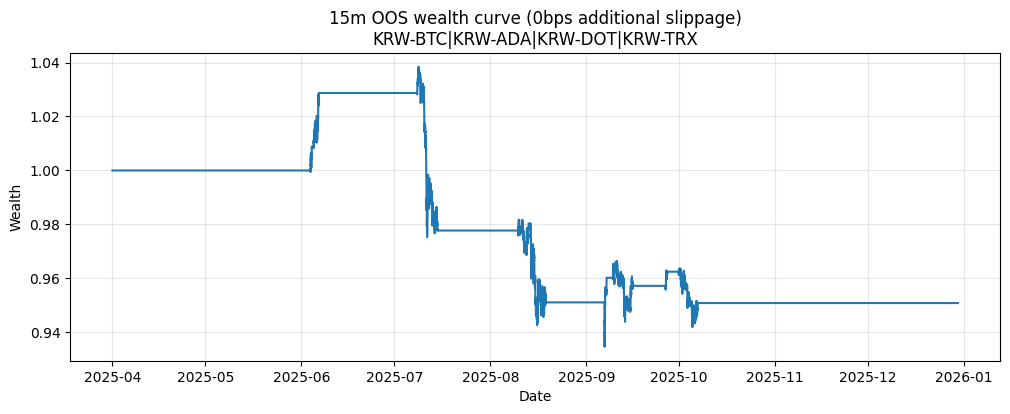

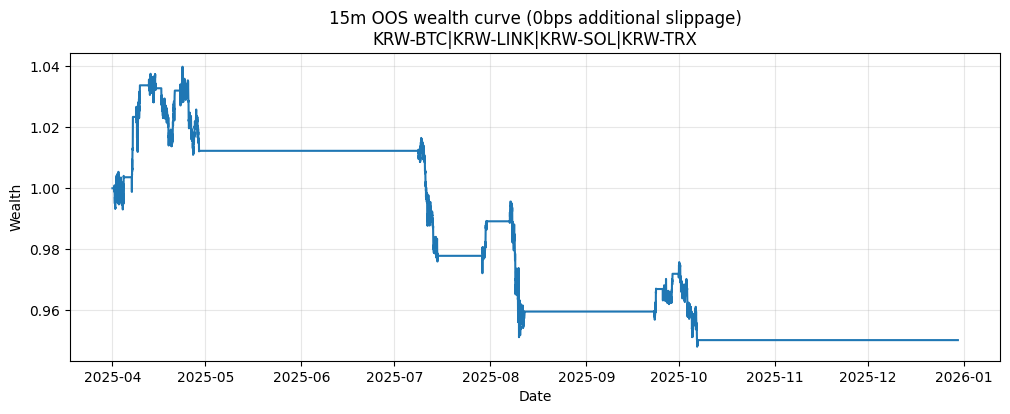

In [8]:
# 0bps 추가 슬리피지 기준 누적 wealth curve

for basket in BASKETS:

    basket_key = "|".join(basket)

    result = all_results[
        (basket_key, 0.0)
    ]

    if result.empty:
        continue

    wealth = np.exp(
        result["net_ret"].cumsum()
    )

    plt.figure(figsize=(12, 4))

    plt.plot(
        wealth.index,
        wealth.values
    )

    plt.title(
        "15m OOS wealth curve "
        "(0bps additional slippage)\n"
        + basket_key
    )

    plt.xlabel("Date")
    plt.ylabel("Wealth")

    plt.grid(
        True,
        alpha=0.3
    )

    plt.show()